# Notebook 03 — Results: Baseline (Momentum) vs Ridge Regression (ML)

## Purpose
This notebook compares:

- **Baseline strategy:** cross-sectional momentum (12-month lookback, top 20%, equal weight, monthly rebalance)
- **ML strategy:** Ridge regression predicting next-month returns and selecting top 20% monthly

We compare both:
- **Train period:** 2015–2024
- **Hold-out test year:** 2025

## Metrics included
- Portfolio performance: return, volatility, Sharpe, drawdown
- Practical stability: turnover
- ML prediction quality (Ridge): MAE, RMSE, R², Spearman rank correlation, top-k hit rate

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Load saved experiment outputs

We load:
- Baseline metrics (train + 2025 test)
- Ridge metrics (train + 2025 test)
- Ridge prediction metrics
- Equity curves for each strategy

In [2]:
BASELINE_DIR = "../experiments/results/exp01_baseline"
RIDGE_DIR = "../experiments/results/exp02_linear_ridge"

# Metrics JSON
BASE_MET_TRAIN = os.path.join(BASELINE_DIR, "metrics_train.json")
BASE_MET_TEST = os.path.join(BASELINE_DIR, "metrics_test_2025.json")

RIDGE_MET_TRAIN = os.path.join(RIDGE_DIR, "metrics_train.json")
RIDGE_MET_TEST = os.path.join(RIDGE_DIR, "metrics_test_2025.json")

RIDGE_PRED_MET = os.path.join(RIDGE_DIR, "prediction_metrics.json")

# Equity curves CSV
BASE_EQUITY_TRAIN = os.path.join(BASELINE_DIR, "equity_train.csv")
BASE_EQUITY_TEST = os.path.join(BASELINE_DIR, "equity_test_2025.csv")

RIDGE_EQUITY_TRAIN = os.path.join(RIDGE_DIR, "equity_train.csv")
RIDGE_EQUITY_TEST = os.path.join(RIDGE_DIR, "equity_test_2025.csv")


def load_json(path: str) -> dict:
    with open(path, "r") as f:
        return json.load(f)

base_train = load_json(BASE_MET_TRAIN)
base_test = load_json(BASE_MET_TEST)

ridge_train = load_json(RIDGE_MET_TRAIN)
ridge_test = load_json(RIDGE_MET_TEST)

ridge_pred = load_json(RIDGE_PRED_MET)

print("Loaded JSON metrics successfully.")

Loaded JSON metrics successfully.


## 2. Build comparison tables

We compare strategy metrics side-by-side for:
- Train (2015–2024)
- Test (2025)

In [3]:
strategy_metrics = [
    "cumulative_return",
    "annualized_return",
    "annualized_volatility",
    "max_drawdown",
    "sharpe_ratio",
    "avg_turnover",
    "median_turnover",
    "max_turnover",
]

train_table = pd.DataFrame({
    "Baseline (Train 2015–2024)": {k: base_train.get(k, np.nan) for k in strategy_metrics},
    "Ridge (Train 2015–2024)": {k: ridge_train.get(k, np.nan) for k in strategy_metrics},
})

test_table = pd.DataFrame({
    "Baseline (Test 2025)": {k: base_test.get(k, np.nan) for k in strategy_metrics},
    "Ridge (Test 2025)": {k: ridge_test.get(k, np.nan) for k in strategy_metrics},
})

display(train_table)
display(test_table)

,Baseline (Train 2015–2024),Ridge (Train 2015–2024)
cumulative_return,1.574280,2.071398
annualized_return,0.099172,0.118751
annualized_volatility,0.130882,0.185761
max_drawdown,-0.255287,-0.335940
sharpe_ratio,0.791859,0.697059
avg_turnover,0.207083,0.556481
median_turnover,0.200000,0.550000
max_turnover,0.550000,0.900000


,Baseline (Test 2025),Ridge (Test 2025)
cumulative_return,0.380870,0.099825
annualized_return,0.380870,0.099825
annualized_volatility,0.130713,0.168340
max_drawdown,-0.068207,-0.113640
sharpe_ratio,2.562589,0.644262
avg_turnover,0.137500,0.518182
median_turnover,0.125000,0.500000
max_turnover,0.350000,0.750000


## 3. Ridge prediction metrics

These metrics evaluate predictive quality for the Ridge model:
- **MAE/RMSE/R²** measure numeric forecast accuracy
- **Spearman rank correlation** measures ranking alignment with realized returns
- **Top-k hit rate** measures overlap between predicted top group and true top group

In [4]:
ridge_pred_train = ridge_pred["train"]
ridge_pred_test = ridge_pred["test_2025"]

pred_table = pd.DataFrame({
    "Ridge Prediction (Train 2015–2024)": {
        **ridge_pred_train["regression"],
        **ridge_pred_train["ranking"]
    },
    "Ridge Prediction (Test 2025)": {
        **ridge_pred_test["regression"],
        **ridge_pred_test["ranking"]
    }
})

display(pred_table)

,Ridge Prediction (Train 2015–2024),Ridge Prediction (Test 2025)
MAE,0.059124,0.055335
RMSE,0.082622,0.074432
R2,0.006042,-0.011885
Directional_Accuracy,0.529412,0.509624
SpearmanRankCorr_mean,0.023740,-0.056690
TopKHitRate_mean,0.244444,0.209091
Months_evaluated,108.000000,11.000000


## 4. Load equity curves and plot

We compare equity curves for:
- Train (2015–2024)
- Test (2025)

Equity curves are shown as cumulative portfolio value.

In [5]:
def load_equity(path: str) -> pd.Series:
    s = pd.read_csv(path, index_col=0).squeeze("columns")
    s.index = pd.to_datetime(s.index)
    return s

eq_base_train = load_equity(BASE_EQUITY_TRAIN)
eq_base_test = load_equity(BASE_EQUITY_TEST)

eq_ridge_train = load_equity(RIDGE_EQUITY_TRAIN)
eq_ridge_test = load_equity(RIDGE_EQUITY_TEST)

print("Equity curves loaded.")

Equity curves loaded.


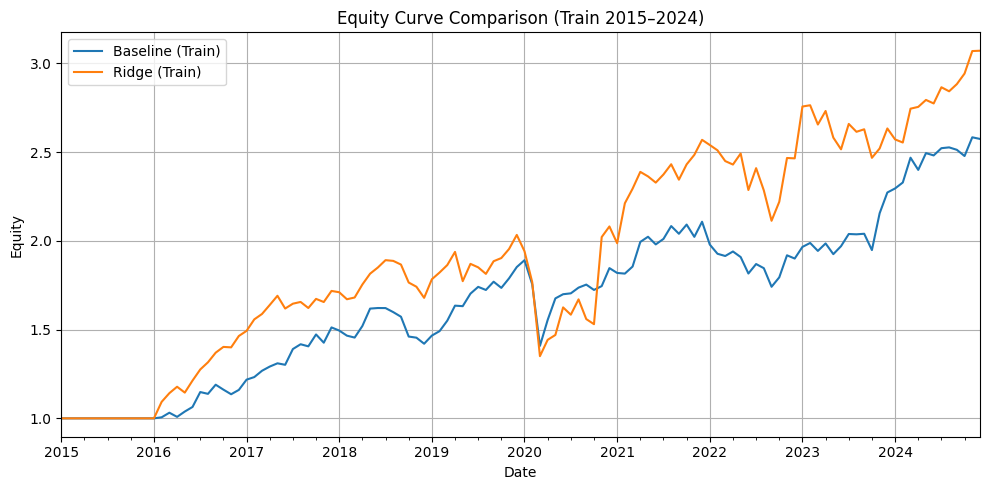

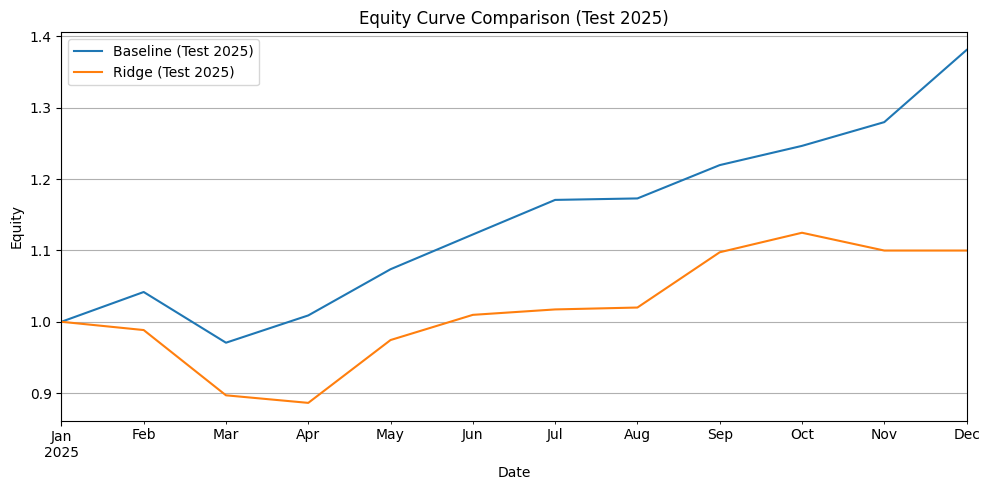

In [6]:
plt.figure(figsize=(10,5))
eq_base_train.plot(label="Baseline (Train)")
eq_ridge_train.plot(label="Ridge (Train)")
plt.title("Equity Curve Comparison (Train 2015–2024)")
plt.xlabel("Date")
plt.ylabel("Equity")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
eq_base_test.plot(label="Baseline (Test 2025)")
eq_ridge_test.plot(label="Ridge (Test 2025)")
plt.title("Equity Curve Comparison (Test 2025)")
plt.xlabel("Date")
plt.ylabel("Equity")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## 5. Drawdown comparison

Drawdown is computed as the percentage fall from the running peak.
It captures the worst "pain" experienced by the strategy.

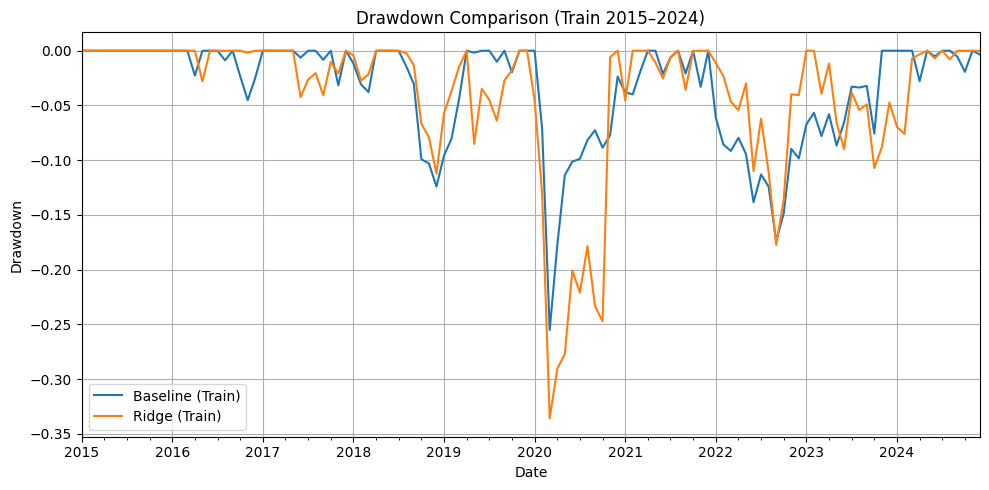

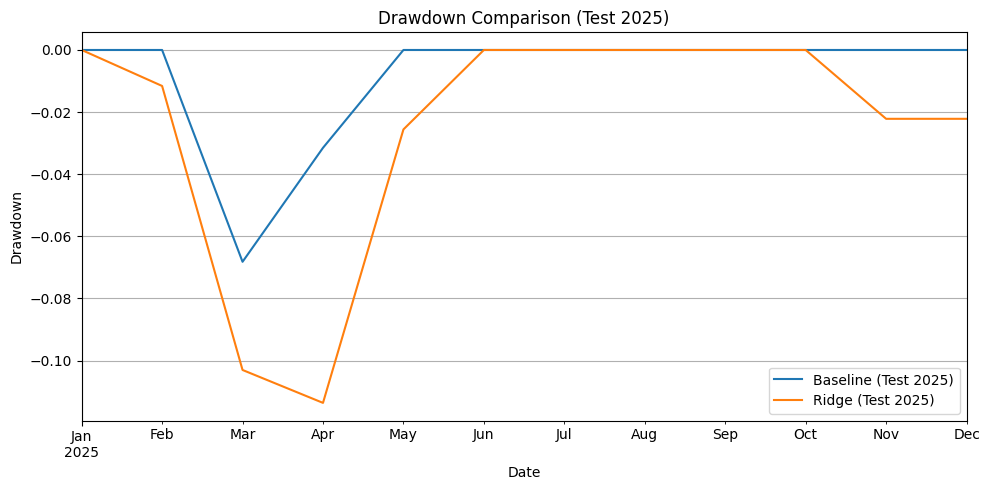

In [7]:
def drawdown(equity: pd.Series) -> pd.Series:
    peak = equity.cummax()
    return equity / peak - 1.0

dd_base_train = drawdown(eq_base_train)
dd_ridge_train = drawdown(eq_ridge_train)

dd_base_test = drawdown(eq_base_test)
dd_ridge_test = drawdown(eq_ridge_test)

plt.figure(figsize=(10,5))
dd_base_train.plot(label="Baseline (Train)")
dd_ridge_train.plot(label="Ridge (Train)")
plt.title("Drawdown Comparison (Train 2015–2024)")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
dd_base_test.plot(label="Baseline (Test 2025)")
dd_ridge_test.plot(label="Ridge (Test 2025)")
plt.title("Drawdown Comparison (Test 2025)")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## 6. Save report-ready figures

We save key plots for the final report to:
`reports/figures/results_baseline_vs_ridge/`

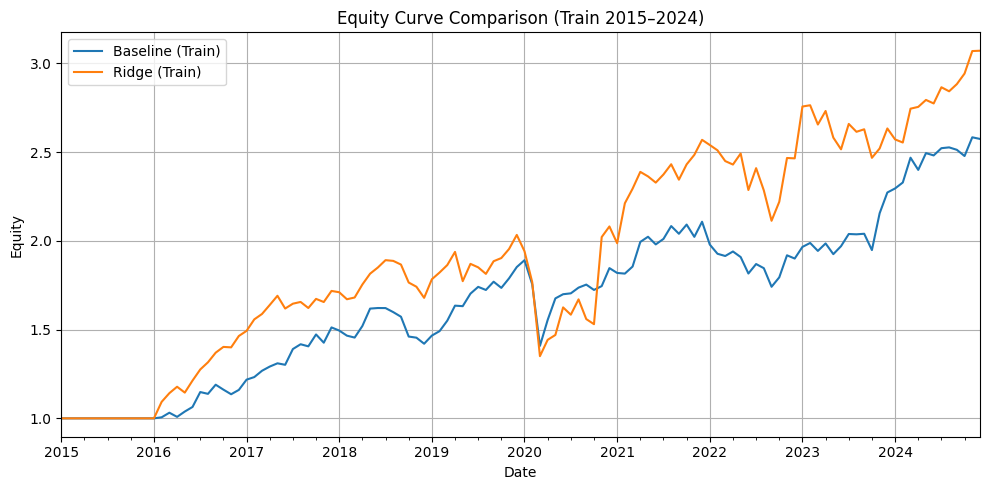

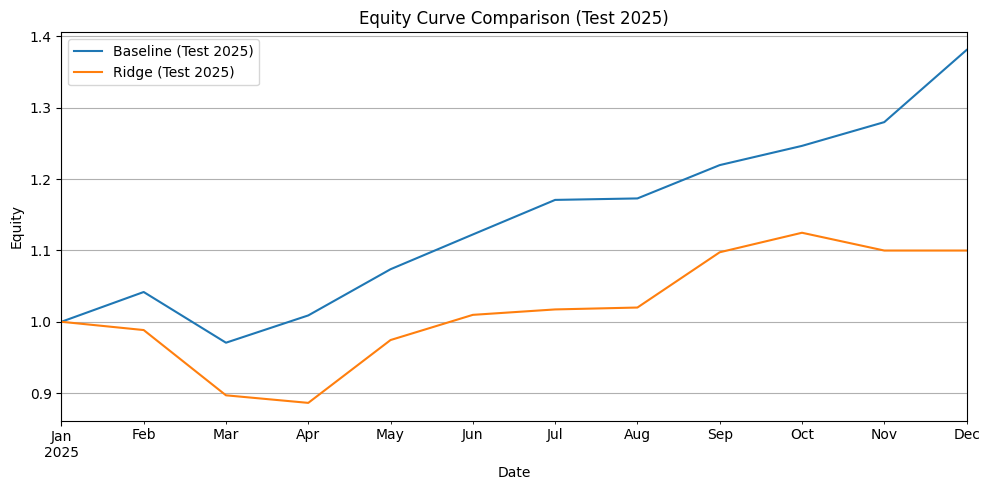

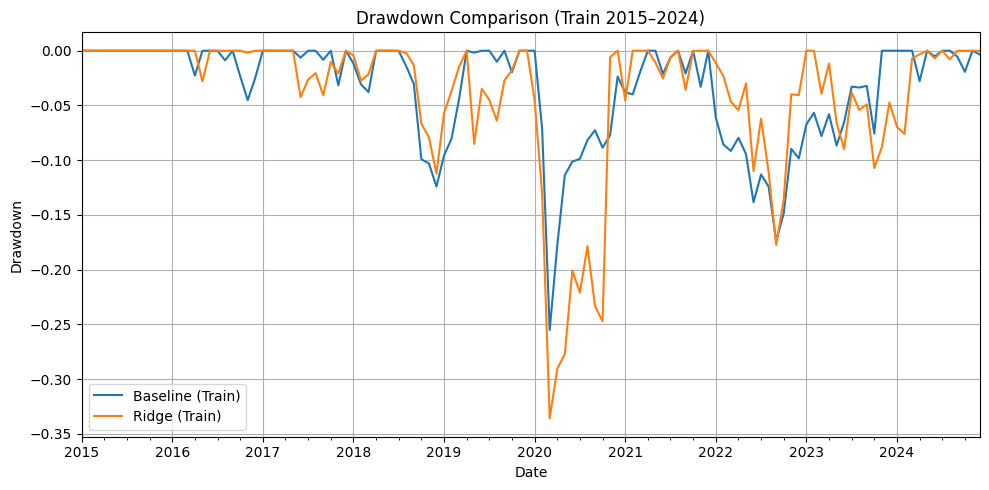

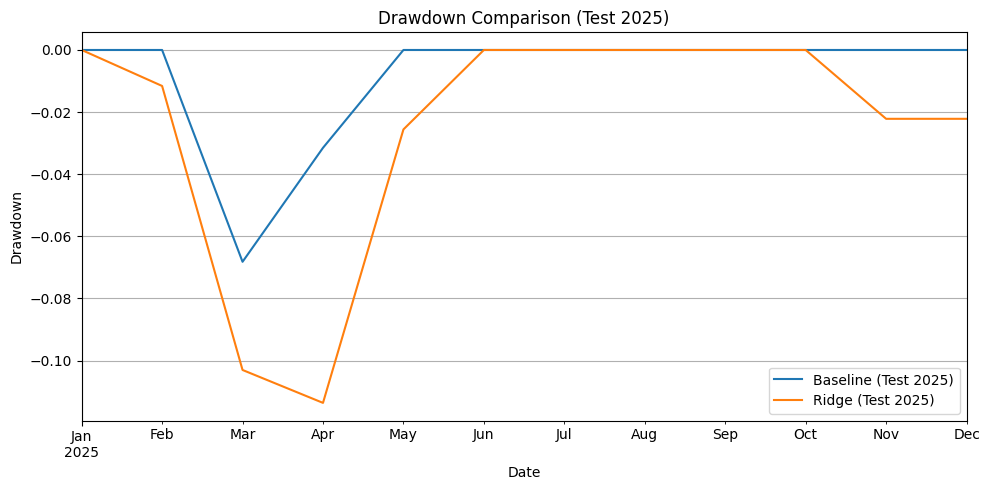

Saved figures and tables to: reports/figures/results_baseline_vs_ridge


In [8]:
OUT_DIR = "reports/figures/results_baseline_vs_ridge"
os.makedirs(OUT_DIR, exist_ok=True)

# Equity curves
plt.figure(figsize=(10,5))
eq_base_train.plot(label="Baseline (Train)")
eq_ridge_train.plot(label="Ridge (Train)")
plt.title("Equity Curve Comparison (Train 2015–2024)")
plt.xlabel("Date")
plt.ylabel("Equity")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "equity_train_baseline_vs_ridge.png"), dpi=200)
plt.show()

plt.figure(figsize=(10,5))
eq_base_test.plot(label="Baseline (Test 2025)")
eq_ridge_test.plot(label="Ridge (Test 2025)")
plt.title("Equity Curve Comparison (Test 2025)")
plt.xlabel("Date")
plt.ylabel("Equity")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "equity_test2025_baseline_vs_ridge.png"), dpi=200)
plt.show()

# Drawdowns
plt.figure(figsize=(10,5))
dd_base_train.plot(label="Baseline (Train)")
dd_ridge_train.plot(label="Ridge (Train)")
plt.title("Drawdown Comparison (Train 2015–2024)")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "drawdown_train_baseline_vs_ridge.png"), dpi=200)
plt.show()

plt.figure(figsize=(10,5))
dd_base_test.plot(label="Baseline (Test 2025)")
dd_ridge_test.plot(label="Ridge (Test 2025)")
plt.title("Drawdown Comparison (Test 2025)")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "drawdown_test2025_baseline_vs_ridge.png"), dpi=200)
plt.show()

# Save tables
train_table.to_csv(os.path.join(OUT_DIR, "strategy_metrics_train.csv"))
test_table.to_csv(os.path.join(OUT_DIR, "strategy_metrics_test2025.csv"))
pred_table.to_csv(os.path.join(OUT_DIR, "ridge_prediction_metrics.csv"))

print("Saved figures and tables to:", OUT_DIR)

## 7. Interpretation

Key observations typically discussed:

- The **baseline momentum strategy** provides a strong benchmark with relatively low turnover.
- Ridge regression may produce competitive returns in certain periods, but often shows:
  - weak predictive accuracy (R² near 0)
  - low/unstable rank correlation (Spearman close to 0)
  - **high turnover**, which reduces practical feasibility once transaction costs are considered.
- Comparing Train vs Test highlights whether ML generalizes out-of-sample, and whether improvements come at the cost of stability.